In [2]:
# create a pytorch dataset and dataloader using the custom dataset class
import torch

import os

# import custom dataset class
from data.dataset import AudioFrameDataset

In [11]:
# implement a custom transform that calculates the mel log spectrogram of a frame of audio data
# It takes a np.ndarray as input and returns a torch.Tensor
import numpy as np
import torchaudio.transforms as T

class MelSpectrogramTransform:
    """
    Converts a 1-D audio frame (np.ndarray) into a flattened log-mel
    spectrogram tensor suitable as autoencoder input.

    Pipeline:
        np.ndarray  →  (1, n_samples) float32 tensor
                    →  MelSpectrogram  →  (1, n_mels, time_bins)
                    →  AmplitudeToDB   →  (1, n_mels, time_bins)  [log scale]
                    →  squeeze + flatten  →  (n_mels * time_bins,)
    """
    def __init__(
        self,
        sample_rate: int = 16000,
        n_fft: int = 512,
        hop_length: int = 160,
        n_mels: int = 64,
    ):
        # Instantiate once; reused across all __getitem__ calls
        self._mel = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
        )
        self._to_db = T.AmplitudeToDB(stype="power", top_db=80.0)

    def __call__(self, frame: np.ndarray) -> torch.Tensor:
        waveform = torch.tensor(frame, dtype=torch.float32).unsqueeze(0)  # (1, n_samples)
        mel = self._mel(waveform)          # (1, n_mels, time_bins)
        mel_db = self._to_db(mel)          # (1, n_mels, time_bins)
        return mel_db.squeeze(0).flatten() # (n_mels * time_bins,)

In [12]:
path_to_data = os.path.join("..", "audio_data", "fan")

In [50]:
sample_rate = 16000
n_mels = 64
dataset = AudioFrameDataset(path_to_data,
                            frame_length=16000, hop_length=8000,
                            target_samplerate=sample_rate,
                            transform=MelSpectrogramTransform(sample_rate=sample_rate,
                                                              n_fft=1024, hop_length=400, n_mels=n_mels))

In [51]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

In [52]:
for batch in dataloader:
    print(batch.shape)
    print(batch)
    break

torch.Size([32, 2624])
tensor([[ -3.3932,  -5.6647,  -7.7839,  ..., -34.6601, -32.8890, -31.3789],
        [ -7.6615,  -8.2302,  -7.2913,  ..., -24.3979, -24.6916, -23.3311],
        [ -1.8020,   4.3777,  -1.1909,  ..., -29.8824, -29.8400, -32.4713],
        ...,
        [ -0.1987,  -4.0180,  -0.4531,  ..., -29.0291, -28.0830, -30.1072],
        [ -3.5259,  -4.5017,  -1.1822,  ..., -32.5772, -30.9261, -32.0252],
        [ 10.3340,   3.8135,  -6.0389,  ..., -28.0992, -28.5070, -27.6046]])


In [53]:
# Take a single batch and reshape it back to (batch_size, n_mels, time_bins) for visualization
batch_size = batch.shape[0]
time_bins = batch.shape[1] // n_mels

In [54]:
batch_reshaped = batch.view(batch_size, n_mels, time_bins)

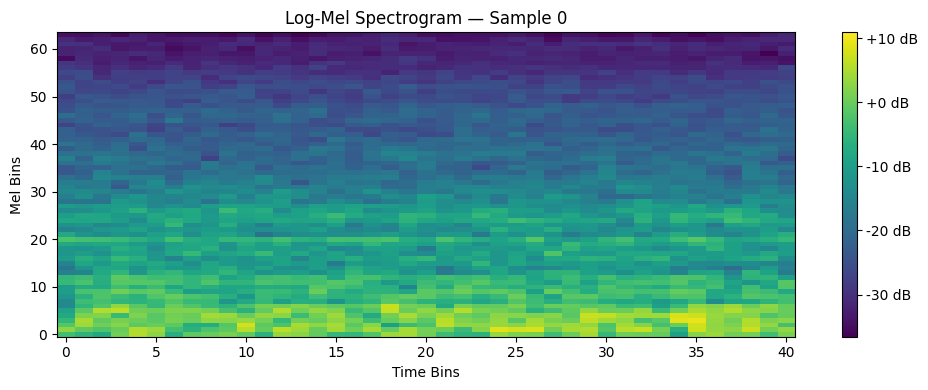

In [60]:
# Visualize the first sample in the batch as a log-mel spectrogram
import matplotlib.pyplot as plt

vmin = batch_reshaped[:2].min().item()
vmax = batch_reshaped[:2].max().item()

plt.figure(figsize=(10, 4))
plt.imshow(batch_reshaped[0].cpu().numpy(), aspect='auto', origin='lower',
           vmin=vmin, vmax=vmax)
plt.title("Log-Mel Spectrogram — Sample 0")
plt.xlabel("Time Bins")
plt.ylabel("Mel Bins")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()

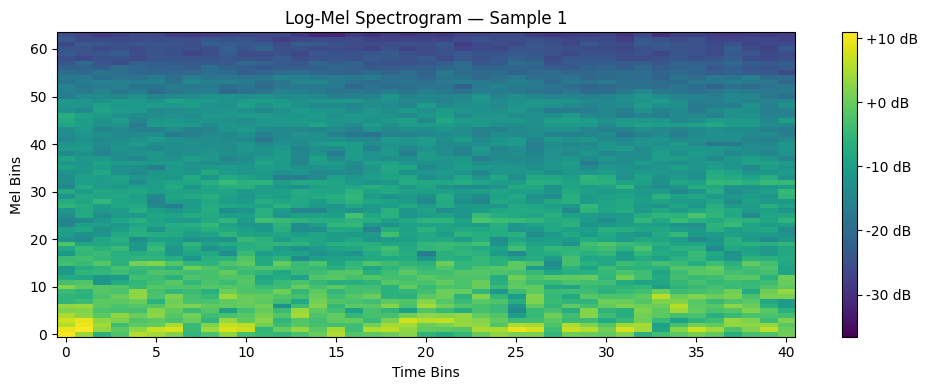

In [63]:
plt.figure(figsize=(10, 4))
plt.imshow(batch_reshaped[31].cpu().numpy(), aspect='auto', origin='lower',
           vmin=vmin, vmax=vmax)
plt.title("Log-Mel Spectrogram — Sample 1")
plt.xlabel("Time Bins")
plt.ylabel("Mel Bins")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()